In [2]:
import os
import pandas as pd
import re

variable_name = "ENERO132V"
folder = f"D:/Datastream/Firmcharacteristics_Monthly/US/"

filenames = os.listdir(os.path.join(folder, variable_name))
df_files = []
for file in filenames:
    df_tmp = pd.read_excel(os.path.join(folder, variable_name, file), sheet_name="Sheet", engine='openpyxl')
    df_tmp = df_tmp.loc[:, ~df_tmp.columns.str.startswith('#ERROR')]
    #extract DSCD codes
    clean_ids = [re.sub(r"\(.*?\)", "", x) for x in df_tmp.iloc[0, 1:].tolist()]
    df_tmp = df_tmp.iloc[2:].copy()
    df_tmp.rename(columns={df_tmp.columns[0]: "Date"}, inplace=True)
    df_tmp["Date"] = pd.to_datetime(df_tmp["Date"])
    df_tmp.loc[:, df_tmp.columns != "Date"] = df_tmp.loc[:, df_tmp.columns != "Date"].apply(pd.to_numeric, errors="coerce")

    df_tmp.columns = ["Date"] + clean_ids
    df_tmp = df_tmp.melt(id_vars = "Date", var_name = "DSCD", value_name = variable_name)
    df_files.append(df_tmp)
    print(f"Finished import of file {file}")

df = pd.concat(df_files)
df = df.dropna(subset=variable_name)
# df.to_csv(os.path.join(folder, "Paneldata", f"{variable_name}.csv"), index = False)

Finished import of file ENERO132V_001.xlsx
Finished import of file ENERO132V_002.xlsx
Finished import of file ENERO132V_003.xlsx
Finished import of file ENERO132V_004.xlsx
Finished import of file ENERO132V_005.xlsx
Finished import of file ENERO132V_006.xlsx
Finished import of file ENERO132V_007.xlsx
Finished import of file ENERO132V_008.xlsx
Finished import of file ENERO132V_009.xlsx
Finished import of file ENERO132V_010.xlsx
Finished import of file ENERO132V_011.xlsx
Finished import of file ENERO132V_012.xlsx
Finished import of file ENERO132V_013.xlsx
Finished import of file ENERO132V_014.xlsx
Finished import of file ENERO132V_015.xlsx
Finished import of file ENERO132V_016.xlsx
Finished import of file ENERO132V_017.xlsx
Finished import of file ENERO132V_018.xlsx
Finished import of file ENERO132V_019.xlsx
Finished import of file ENERO132V_020.xlsx
Finished import of file ENERO132V_021.xlsx
Finished import of file ENERO132V_022.xlsx
Finished import of file ENERO132V_023.xlsx
Finished im

<Axes: xlabel='Date'>

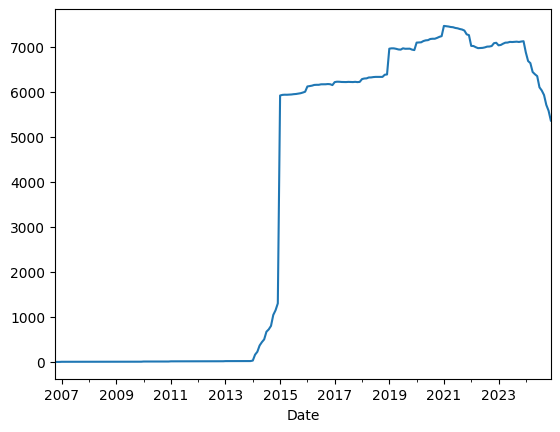

In [3]:
df.groupby("Date").size().plot()

<Axes: xlabel='Date'>

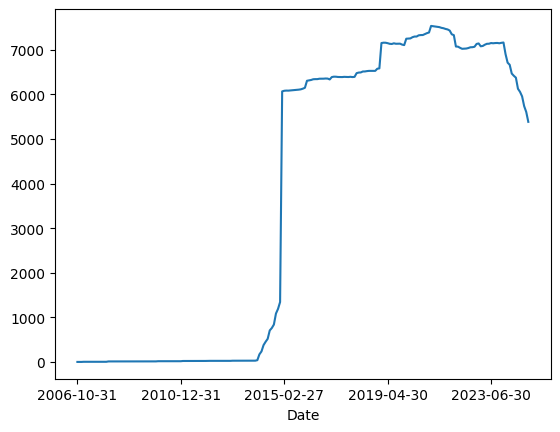

In [6]:
import pandas as pd

enero_117v = pd.read_csv("D:\\Datastream\\Firmcharacteristics_Monthly\\US\\Paneldata\\ENERO117V.csv")
enero_117v.groupby("Date").size().plot()